# Frame-Level Pseudo-Labelling

Turns the segmentation of `sofi_algorithm2.ipynb` into an actual **training set**: every frame
of every usable clip gets a letter label, or `<TRANS>` for transition frames, or `None` where
MediaPipe lost the hand.

### The key move: labelling is not inference

At inference time we would not know how many letters a clip contains. At *labelling* time we
do — the filename gives the word, and `word_letter_mapping.json` gives its ordered letter
sequence. So rather than running free segmentation and hoping the count comes out right (it
does for only ~32 % of clips), we **constrain** the segmenter to emit exactly
`k = len(letters)` holds.

That converts a brittle detection problem into an exact alignment problem, solved by DP in
`pseudo_label.select_k_minima`: choose exactly k frames minimising total OFI subject to a
minimum separation. Segment *i* then maps to letter *i*, because fingerspelling is strictly
sequential — no reordering, no insertion.

### What this assumes

1. **Every letter is spelled, none skipped or merged.** If a signer elides a letter, all
   subsequent labels in that clip shift by one. Not directly detectable; the diagnostics below
   are the proxy.
2. **The filename records what was actually signed.** Mostly true, but 4 clips have
   spellings whose canonical form has a different letter count — flagged, not silently merged
   (see `canonicalize_words.py`).
3. **The deepest k minima are the holds.** Reasonable for fingerspelling; checked below against
   what unconstrained detection independently finds.

## Setup

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from canonicalize_words import canonicalize, spelling_for_labels, is_ambiguous_spelling
from sofi_dynamic import ofi_signal, find_local_minima, collapse_minima, DEFAULT_RUN, DEFAULT_MIN_SEP
from pseudo_label import label_clip, select_k_minima, TRANSITION

CSV_PATH = "hand_keypoints_features.csv"
MAPPING_PATH = "word_letter_mapping.json"
VIDEO_ROOT = "PSL_Fingerspelling_Video_Dataset_Cropped/PSL_Fingerspelling_Video_Dataset_Cropped"

pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv(CSV_PATH)
mapping = json.load(open(MAPPING_PATH, encoding="utf-8"))

_raw = df["video_id"].unique()
df["word"] = df["video_id"].map({v: canonicalize(v) for v in _raw})
df["spelling"] = df["video_id"].map({v: spelling_for_labels(v) for v in _raw})

clips = []
for (sg, vid), sub in df.groupby(["signer_id", "video_id"], sort=True):
    sub = sub.sort_values("frame_id").reset_index(drop=True)
    sp = sub["spelling"].iloc[0]
    if sp not in mapping or sub["hand_detected"].mean() < 0.5 or len(sub) < 30:
        continue
    clips.append({"signer": sg, "video_id": vid, "word": sub["word"].iloc[0], "spelling": sp,
                  "letters": mapping[sp], "ambiguous": is_ambiguous_spelling(vid), "sub": sub})

print(f"{len(clips)} clips to pseudo-label")
print(f"  of which flagged ambiguous-spelling: {sum(c['ambiguous'] for c in clips)}")

218 clips to pseudo-label
  of which flagged ambiguous-spelling: 6


## Constrained vs. free segmentation, on one clip

Green = the k picks the DP chose (one per letter). Red dashed = what unconstrained
detection found on its own. Where they coincide, the constraint changed nothing; where they
differ, the constraint is doing work.

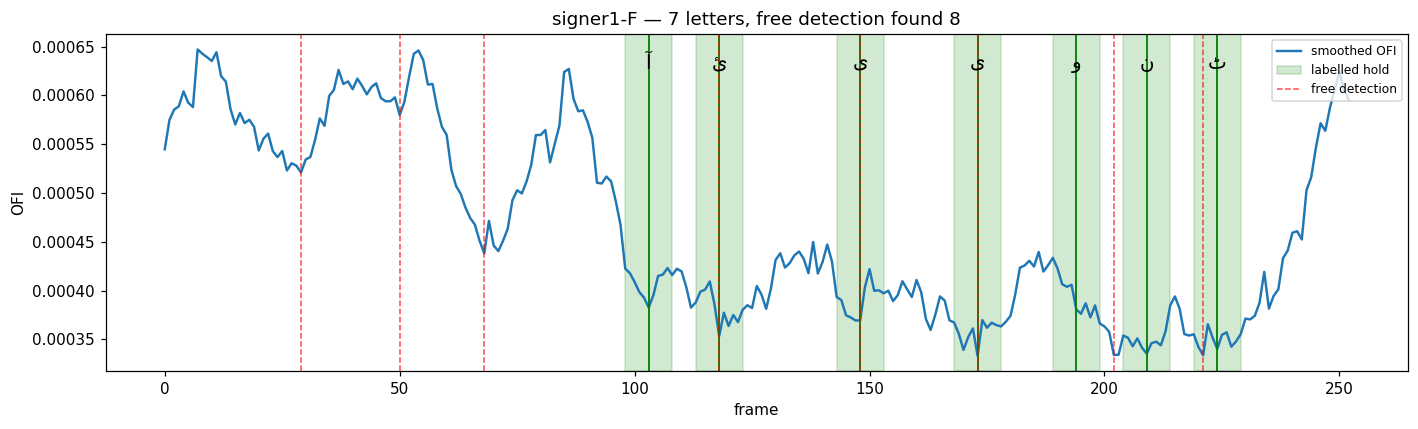

alignment_confidence = 0.57  (fraction of picks corroborated by free detection)


In [3]:
demo = next(c for c in clips if len(c["letters"]) >= 6 and not c["ambiguous"])
labels, info = label_clip(demo["sub"], demo["letters"])
raw, smooth, bad = ofi_signal(demo["sub"])
free = collapse_minima(find_local_minima(smooth, DEFAULT_RUN), smooth, DEFAULT_MIN_SEP)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(smooth, lw=1.6, color="C0", label="smoothed OFI")
for j, (a, b) in enumerate(info["segments"]):
    ax.axvspan(a, b, color="green", alpha=0.18, label="labelled hold" if j == 0 else None)
for j, m in enumerate(info["minima"]):
    ax.axvline(m, color="green", lw=1.2)
    ax.text(m, ax.get_ylim()[1] * 0.97, demo["letters"][j], ha="center", va="top", fontsize=13)
for j, m in enumerate(free):
    ax.axvline(m, color="red", ls="--", alpha=0.7, lw=1,
               label="free detection" if j == 0 else None)
ax.set_xlabel("frame"); ax.set_ylabel("OFI")
ax.set_title(f"{demo['signer']} — {len(demo['letters'])} letters, "
             f"free detection found {len(free)}")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

print(f"alignment_confidence = {info['alignment_confidence']:.2f}  "
      f"(fraction of picks corroborated by free detection)")

## Label every clip

In [4]:
frame_rows, clip_rows = [], []
for c in clips:
    labels, info = label_clip(c["sub"], c["letters"])
    info.update(signer_id=c["signer"], video_id=c["video_id"], word=c["word"],
                spelling=c["spelling"], ambiguous=c["ambiguous"],
                detect_rate=float(c["sub"]["hand_detected"].mean()))
    clip_rows.append(info)
    if labels is None:
        continue
    letter_idx = np.full(len(labels), -1, dtype=int)
    for i, (a, b) in enumerate(info["segments"]):
        letter_idx[a:b + 1] = i
    frame_rows.append(pd.DataFrame({
        "signer_id": c["signer"], "video_id": c["video_id"], "spelling": c["spelling"],
        "frame_id": c["sub"]["frame_id"].to_numpy(),
        "label": labels,
        "letter_index": np.where(np.array([l is not None and l != TRANSITION for l in labels]),
                                 letter_idx, -1),
    }))

frames = pd.concat(frame_rows, ignore_index=True)
clip_info = pd.DataFrame(clip_rows)

print(f"{len(clip_info)} clips, statuses: {clip_info.status.value_counts().to_dict()}")
usable = frames[frames.label.notna()]
print(f"{len(frames):,} frames total, {len(usable):,} usable "
      f"({(frames.label.isna()).sum():,} dropped: MediaPipe miss)")
print(f"  hold frames:       {(usable.label != TRANSITION).sum():,}")
print(f"  transition frames: {(usable.label == TRANSITION).sum():,}")

218 clips, statuses: {'ok': 218}
42,795 frames total, 41,930 usable (865 dropped: MediaPipe miss)
  hold frames:       14,530
  transition frames: 27,400


## Labelling-quality diagnostics

No ground truth exists, so we rank clips by three proxies rather than claiming an accuracy:

| Diagnostic | Meaning | Good |
|---|---|---|
| `alignment_confidence` | fraction of the k picks that unconstrained detection also found | high — the constraint agreed with the evidence |
| `mean_pick_depth` | OFI at the picks / median OFI of the clip | low — picks sit in real troughs, not on the slope |
| `seg_detect_rate` | fraction of labelled hold frames MediaPipe actually saw | high |
| `count_error` | free-detection count minus true letter count | near 0 |

                      count   mean    std    min    25%    50%    75%    max
alignment_confidence  218.0  0.705  0.193  0.250  0.571  0.714  0.833  1.000
mean_pick_depth       218.0  0.756  0.117  0.238  0.710  0.786  0.834  1.049
seg_detect_rate       218.0  0.974  0.094  0.420  1.000  1.000  1.000  1.000
count_error           218.0 -0.005  1.729 -9.000 -1.000  0.000  1.000  4.000


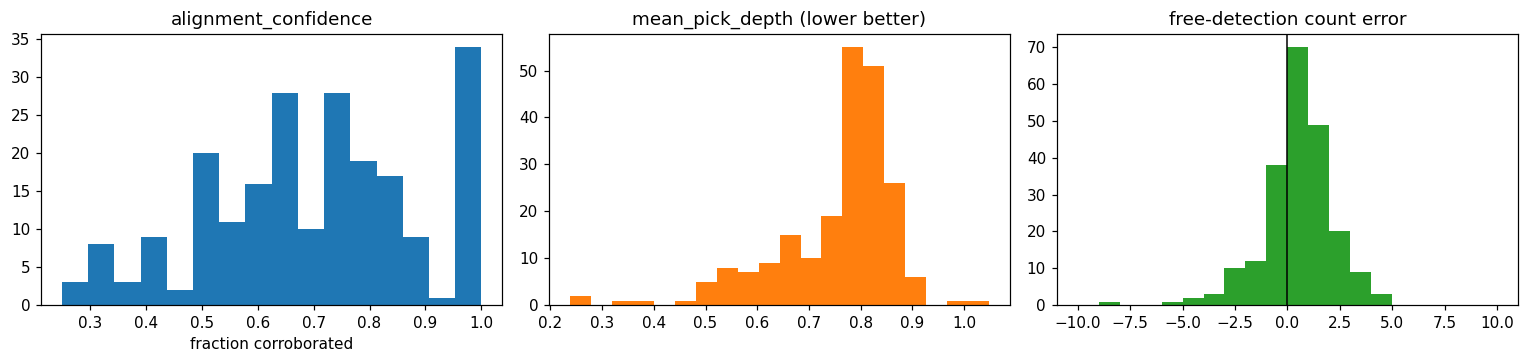

In [5]:
ok = clip_info[clip_info.status == "ok"]
print(ok[["alignment_confidence", "mean_pick_depth", "seg_detect_rate", "count_error"]]
      .describe().round(3).T.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].hist(ok.alignment_confidence, bins=16, color="C0")
axes[0].set_title("alignment_confidence"); axes[0].set_xlabel("fraction corroborated")
axes[1].hist(ok.mean_pick_depth, bins=20, color="C1")
axes[1].set_title("mean_pick_depth (lower better)")
axes[2].hist(ok.count_error, bins=range(-10, 11), color="C2")
axes[2].axvline(0, color="k", lw=1)
axes[2].set_title("free-detection count error")
plt.tight_layout(); plt.show()

In [6]:
# a single 0-1 quality score, for ranking which clips to trust and which to review
q = ok.copy()
q["quality"] = (q.alignment_confidence
                - 0.5 * q.mean_pick_depth
                - 0.03 * q.count_error.abs()
                + 0.3 * q.seg_detect_rate)
q["quality"] = (q.quality - q.quality.min()) / (q.quality.max() - q.quality.min())
q.loc[q.ambiguous, "quality"] *= 0.5   # penalise the 4 flagged spellings

print("per-signer labelling quality:")
print(q.groupby("signer_id").agg(
    clips=("quality", "size"),
    mean_quality=("quality", "mean"),
    mean_align_conf=("alignment_confidence", "mean"),
    mean_count_err=("count_error", lambda s: s.abs().mean())).round(3).to_string())

print("\n10 lowest-quality clips (review these first):")
print(q.nsmallest(10, "quality")[
    ["signer_id", "spelling", "n_letters", "n_free_segments",
     "alignment_confidence", "mean_pick_depth", "quality"]].round(3).to_string(index=False))

per-signer labelling quality:
           clips  mean_quality  mean_align_conf  mean_count_err
signer_id                                                      
signer1-F     49         0.517            0.755           1.408
signer2-F     49         0.471            0.701           0.980
signer3-F     45         0.471            0.720           1.311
signer4-L     49         0.519            0.686           1.265
signer5-R     26         0.418            0.625           0.731

10 lowest-quality clips (review these first):
signer_id           spelling  n_letters  n_free_segments  alignment_confidence  mean_pick_depth  quality
signer4-L               طاقت          4                1                 0.250            0.778    0.000
signer1-F سٹینڈرڈ چارٹرڈ بنک         16                7                 0.562            1.003    0.017
signer4-L         الحبیب بنک          9                4                 0.444            0.922    0.026
signer4-L           آئی یونٹ          7                

## Failure mode: constraint-dominated alignment

Forcing exactly k picks has a cost. When a word has more letters than the clip has room for,
the DP cannot find k separated troughs, the relaxation loop lowers `min_sep`, and the solution
degenerates into **tiling the clip at the separation floor** — evenly spaced picks that land
mid-transition rather than on holds.

`spot_check/signer1-F__00.png` is the clearest example: a 16-letter word in 150 frames, picks
landing at frames 7, 16, 25, 34 ... 142 — exactly 9 apart, with no variation. The thumbnails
show blurred, near-identical hands rather than 16 distinct letters.

This is detectable without looking, via three independent symptoms, and `label_clip` now flags
it as `constraint_dominated`.

In [7]:
flagged = clip_info[clip_info.constraint_dominated]
print(f"{len(flagged)} of {len(clip_info)} clips flagged constraint-dominated")
print()
print(clip_info.groupby("constraint_dominated")[
    ["gap_cv", "frames_per_letter", "mean_pick_depth", "alignment_confidence", "n_letters"]
].mean().round(3).to_string())
print()
print("flagged clips:")
print(flagged[["signer_id", "spelling", "n_letters", "n_frames", "frames_per_letter",
               "gap_cv", "mean_pick_depth", "min_sep_used"]].round(3).to_string(index=False))

6 of 218 clips flagged constraint-dominated

                      gap_cv  frames_per_letter  mean_pick_depth  alignment_confidence  n_letters
constraint_dominated                                                                             
False                  0.417             32.940            0.752                 0.711      6.217
True                   0.000             13.691            0.909                 0.489      8.000

flagged clips:
signer_id           spelling  n_letters  n_frames  frames_per_letter  gap_cv  mean_pick_depth  min_sep_used
signer1-F سٹینڈرڈ چارٹرڈ بنک         16       150              9.375     0.0            1.003             9
signer3-F               جناح          4       113             28.250     NaN            0.906            15
signer4-L           آئی یونٹ          7        96             13.714     0.0            1.049            12
signer4-L         الحبیب بنک          9       104             11.556     0.0            0.922             9
signer4

Flagged clips sit at `mean_pick_depth` ~0.91 — their picks are at ~91 % of the clip's typical
motion, i.e. not in troughs at all — against ~0.75 for the rest, and average under 11 frames
per letter versus ~33.

Only a handful of clips are affected, so this is a **precision fix, not a rescue**: excluding
them lifts within-signer letter accuracy measurably for two signers (see
`letter_classifier.ipynb`) but changes none of the headline conclusions. It is worth keeping
because the failure is silent otherwise — these clips produce confident-looking labels that
are simply wrong.

A real fix would drop the fixed `seg_len` and let hold length adapt to the signing rate, so a
fast clip gets short holds rather than an infeasible spacing constraint.

## Sanity check: do the labels behave like labels?

Three checks that need no human review. None proves the labels are *correct*, but each would
fail loudly if they were noise.

In [8]:
# 1. Hold frames should have materially lower motion than transition frames.
mot = []
for c in clips[:]:
    _, sm, _ = ofi_signal(c["sub"])
    lab, inf = label_clip(c["sub"], c["letters"])
    if lab is None:
        continue
    m = np.array([l is not None and l != TRANSITION for l in lab])
    if m.any() and (~m).any():
        mot.append((sm[m].mean(), sm[~m].mean()))
mot = np.array(mot)
print(f"mean OFI at hold frames:       {mot[:,0].mean():.5f}")
print(f"mean OFI at transition frames: {mot[:,1].mean():.5f}")
print(f"ratio: {mot[:,1].mean()/mot[:,0].mean():.2f}x  "
      f"(holds quieter in {100*(mot[:,0]<mot[:,1]).mean():.1f}% of clips)")

mean OFI at hold frames:       0.00162
mean OFI at transition frames: 0.00344
ratio: 2.12x  (holds quieter in 100.0% of clips)


In [9]:
# 2. Labelled holds should be roughly evenly spread through the clip, since
#    fingerspelling is paced. Wildly clumped picks would indicate the DP latched
#    onto one quiet region.
spread = []
for r in ok.itertuples():
    m = np.array(r.minima)
    if len(m) > 2:
        gaps = np.diff(m)
        spread.append(gaps.std() / gaps.mean())   # coefficient of variation
print(f"gap coefficient-of-variation: median {np.median(spread):.2f}, "
      f"90th pct {np.percentile(spread,90):.2f}")
print("(0 = perfectly even; >1 would mean badly clumped)")

gap coefficient-of-variation: median 0.36, 90th pct 0.65
(0 = perfectly even; >1 would mean badly clumped)


In [10]:
# 3. The same letter, signed in DIFFERENT words, should look alike.
#    If pseudo-labels were noise, within-letter spread would match between-letter spread.
D_COLS = [c for c in df.columns if c.startswith("d_")]

key = frames[(frames.label.notna()) & (frames.label != TRANSITION)][
    ["signer_id", "video_id", "frame_id", "label", "spelling"]]
feat = key.merge(df[["signer_id", "video_id", "frame_id"] + D_COLS],
                 on=["signer_id", "video_id", "frame_id"], how="left")

# one mean feature vector per (clip, letter-occurrence)
X = feat.groupby(["signer_id", "spelling", "label"])[D_COLS].mean()
Xz = (X - X.mean()) / X.std()
letters_of = Xz.index.get_level_values("label").to_numpy()

from scipy.spatial.distance import pdist, squareform
Dm = squareform(pdist(Xz.to_numpy()))
same = letters_of[:, None] == letters_of[None, :]
np.fill_diagonal(same, False)
np.fill_diagonal(Dm, np.nan)

within = np.nanmean(Dm[same])
between = np.nanmean(Dm[~same & ~np.isnan(Dm)])
print(f"mean distance, same letter (different words/signers): {within:.2f}")
print(f"mean distance, different letters:                     {between:.2f}")
print(f"separation ratio: {between/within:.3f}   (1.0 = labels carry no signal)")

mean distance, same letter (different words/signers): 5.05
mean distance, different letters:                     5.03
separation ratio: 0.998   (1.0 = labels carry no signal)


## Export

`pseudo_labels.csv` — one row per frame (frame_id indexes the video directly; verified
identical to the video frame count for all 353 clips).
`pseudo_label_clips.csv` — per-clip diagnostics and quality score.

In [11]:
frames.to_csv("pseudo_labels.csv", index=False, encoding="utf-8")
q.drop(columns=["minima", "segments"]).to_csv("pseudo_label_clips.csv", index=False, encoding="utf-8")

# segment bounds kept separately -- needed by the spot-check sheets and the classifier
seg_rows = [{"signer_id": r.signer_id, "video_id": r.video_id, "spelling": r.spelling,
             "letter_index": i, "letter": r.letters_list[i], "minimum_frame": m,
             "start": a, "end": b}
            for r in q.assign(letters_list=q.spelling.map(mapping)).itertuples()
            for i, (m, (a, b)) in enumerate(zip(r.minima, r.segments))]
pd.DataFrame(seg_rows).to_csv("pseudo_label_segments.csv", index=False, encoding="utf-8")

print("wrote pseudo_labels.csv, pseudo_label_clips.csv, pseudo_label_segments.csv")
print(f"  {len(frames):,} frame rows / {len(seg_rows):,} segment rows")

wrote pseudo_labels.csv, pseudo_label_clips.csv, pseudo_label_segments.csv
  42,795 frame rows / 1,366 segment rows


## Per-letter yield

How much training data each letter actually gets. Frames within one clip are highly correlated,
so **distinct clip-occurrences** is the number that matters, not frame count.

In [12]:
held = frames[(frames.label.notna()) & (frames.label != TRANSITION)]
yield_tbl = (held.groupby("label")
             .agg(frames=("frame_id", "size"),
                  occurrences=("video_id", lambda s: len(s.unique())),
                  words=("spelling", "nunique"),
                  signers=("signer_id", "nunique"))
             .sort_values("occurrences"))
print(yield_tbl.to_string())
print(f"\n{len(yield_tbl)} letter classes")
print(f"letters appearing in only one word: {(yield_tbl.words == 1).sum()}")

       frames  occurrences  words  signers
label                                     
ث          55            1      1        5
خ          55            1      1        5
ذ          55            1      1        5
ص          44            1      1        4
ط          44            1      1        5
پ          44            1      1        4
ژ          49            1      1        5
ڑ          44            1      1        4
ق          92            2      2        5
ظ         102            2      2        5
غ         110            2      2        5
ش          88            2      2        5
ض         110            2      2        5
ے         160            3      3        5
آ         143            3      3        5
ز         132            3      3        4
چ          86            4      3        4
ف         149            4      3        5
ت         201            4      4        5
ؤ          77            4      2        4
ھ         143            4      3        5
د         1

C:\Users\H.P\AppData\Local\Temp\ipykernel_62572\4182947304.py:7: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\H.P\AppData\Local\Temp\ipykernel_62572\4182947304.py:7: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout(); plt.show()
C:\Users\H.P\AppData\Local\Temp\ipykernel_62572\4182947304.py:7: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


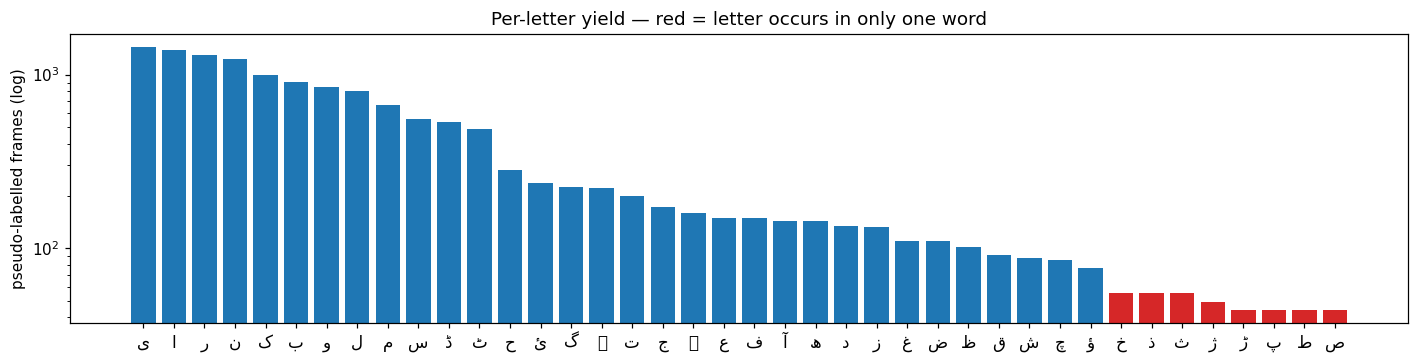

In [13]:
fig, ax = plt.subplots(figsize=(13, 3.4))
yt = yield_tbl.sort_values("frames", ascending=False)
ax.bar(range(len(yt)), yt.frames, color=["C3" if w == 1 else "C0" for w in yt.words])
ax.set_xticks(range(len(yt)), yt.index, fontsize=11)
ax.set_yscale("log"); ax.set_ylabel("pseudo-labelled frames (log)")
ax.set_title("Per-letter yield — red = letter occurs in only one word")
plt.tight_layout(); plt.show()

The imbalance is severe and **structural**: a letter appearing in one word can only ever have
as many independent occurrences as there are signers of that word (≤5). No amount of frame-level
augmentation creates new handshape variation there. Red bars are the letters for which any
reported accuracy is close to meaningless.

## Spot-check material

Generates a contact sheet per clip: the frame at each chosen minimum, in order, captioned with
the letter the pipeline assigned. Reviewing one sheet answers "is segment *i* really letter *i*?"
without scrubbing video.

`spot_check/review.csv` is a pre-filled template — fill the `verdict` column
(`ok` / `shifted` / `wrong` / `unclear`) per clip.

**Sampling is stratified across signers and deliberately spans the quality range**, so the
resulting estimate covers bad clips as well as good ones.

In [14]:
import cv2

SPOT_DIR = "spot_check"
os.makedirs(SPOT_DIR, exist_ok=True)

def contact_sheet(row, letters, out_path, thumb=(170, 240)):
    """Tile the frame at each chosen minimum, in signing order, with its label."""
    path = os.path.join(VIDEO_ROOT, row.signer_id, row.video_id)
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        return False
    imgs = []
    for m in row.minima:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(m))
        ok_, fr = cap.read()
        imgs.append(cv2.resize(fr, thumb) if ok_ else np.zeros((thumb[1], thumb[0], 3), np.uint8))
    cap.release()

    n = len(imgs)
    ncol = min(n, 8); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.55 * ncol, 2.5 * nrow), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for i, im in enumerate(imgs):
        ax = axes[i // ncol][i % ncol]
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        # Urdu letters render right-to-left; a single isolated letter needs no
        # reshaping, so plot it directly.
        ax.set_title(f"{i+1}. {letters[i]}   f{row.minima[i]}", fontsize=11)
    fig.suptitle(f"{row.signer_id}   |   {row.spelling}   |   "
                 f"{n} letters   |   align_conf={row.alignment_confidence:.2f}",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(out_path, dpi=85, bbox_inches="tight")
    plt.close(fig)
    return True

print("contact_sheet() ready")

contact_sheet() ready


In [15]:
# stratified sample: per signer, take clips spanning the quality range
rng = np.random.default_rng(7)
sample = []
for sg, grp in q.groupby("signer_id"):
    grp = grp.sort_values("quality")
    n = min(4, len(grp))
    idx = np.linspace(0, len(grp) - 1, n).round().astype(int)   # worst .. best
    sample.append(grp.iloc[idx])
sample = pd.concat(sample).reset_index(drop=True)

made = 0
for i, row in sample.iterrows():
    fname = f"{row.signer_id}__{i:02d}.png"
    if contact_sheet(row, mapping[row.spelling], os.path.join(SPOT_DIR, fname)):
        sample.loc[i, "sheet"] = fname
        made += 1

review = sample[["sheet", "signer_id", "spelling", "n_letters",
                 "alignment_confidence", "mean_pick_depth", "quality"]].copy()
review["verdict"] = ""      # ok | shifted | wrong | unclear
review["n_letters_correct"] = ""
review["notes"] = ""
review.to_csv(os.path.join(SPOT_DIR, "review.csv"), index=False, encoding="utf-8-sig")

print(f"wrote {made} contact sheets + review.csv to {SPOT_DIR}/")
print(review[["sheet", "signer_id", "spelling", "n_letters", "quality"]].round(3).to_string(index=False))

wrote 20 contact sheets + review.csv to spot_check/
            sheet signer_id           spelling  n_letters  quality
signer1-F__00.png signer1-F سٹینڈرڈ چارٹرڈ بنک         16    0.017
signer1-F__01.png signer1-F           گنگا رام          7    0.471
signer1-F__02.png signer1-F     ٹھوکر نیاز بیگ         12    0.583
signer1-F__03.png signer1-F               کومل          4    0.784
signer2-F__04.png signer2-F          عسکری بنک          8    0.081
signer2-F__05.png signer2-F            رائیونڈ          7    0.359
signer2-F__06.png signer2-F               اکرم          4    0.559
signer2-F__07.png signer2-F               راحت          4    0.776
signer3-F__08.png signer3-F         الائیڈ بنک          9    0.033
signer3-F__09.png signer3-F         سونیری بنک          9    0.383
signer3-F__10.png signer3-F     کیکس اینڈ بیکس         12    0.539
signer3-F__11.png signer3-F               ذرات          4    0.768
signer4-L__12.png signer4-L               طاقت          4    0.000
signer4-L_

### How to review

For each sheet, check that the thumbnails read as a sequence of **distinct, settled
handshapes** matching the captioned letters in order. The three failure modes to look for:

- **shifted** — handshapes look right but are off by one position (a letter was elided or
  double-counted). Still salvageable: re-align and relabel.
- **wrong** — thumbnails land mid-transition (motion-blurred, hand between poses). The DP
  picked slopes, not troughs; expect low `alignment_confidence`.
- **unclear** — hand occluded or out of frame.

Record verdicts in `spot_check/review.csv`. With ~20 clips a `wrong` rate of 2/20 estimates
labelling noise at roughly 10 % ±7 % — coarse, but enough to know whether the classifier's
ceiling is set by the labels or by the model.

**This step needs a human who reads Urdu and knows the PSL handshapes** — it is the one part of
the pipeline that cannot be automated, and the reason the sheets exist.

## Known limitation: picks near the clip boundary

`select_k_minima` keeps picks `margin = run = 7` frames away from the clip edges. Inspecting
the contact sheets shows that is too generous at 50 fps — `spot_check/signer5-R__19.png` has
`alignment_confidence = 1.00` yet its final pick lands while the hand is still moving out of
frame, and the thumbnail is visibly motion-blurred.

Measured below. The clip edges are where the hand enters and leaves, so the OFI signal there is
low for the wrong reason (nothing in frame moving yet) — a trough the DP is happy to choose.

In [16]:
seg = pd.read_csv("pseudo_label_segments.csv")
mm = seg.merge(clip_info[["signer_id", "video_id", "n_frames", "n_letters"]],
               on=["signer_id", "video_id"])
mm["from_end"] = mm.n_frames - 1 - mm.minimum_frame
last = mm[mm.letter_index == mm.n_letters - 1]
first = mm[mm.letter_index == 0]
print(f"last pick within 15 frames (0.3 s) of clip end:   "
      f"{int((last.from_end < 15).sum())} / {len(last)} clips")
print(f"first pick within 15 frames of clip start:        "
      f"{int((first.minimum_frame < 15).sum())} / {len(first)} clips")
print()
print("distance of the last pick from the clip end:")
print(last.from_end.describe(percentiles=[.05, .25, .5]).round(1).to_string())

last pick within 15 frames (0.3 s) of clip end:   34 / 218 clips
first pick within 15 frames of clip start:        38 / 218 clips

distance of the last pick from the clip end:
count    218.0
mean      25.4
std       13.4
min        7.0
5%         7.9
25%       17.0
50%       22.0
max       84.0


Roughly one clip in six has a boundary pick inside 0.3 s of the edge. Raising the margin to
~15 frames is the obvious fix, but it is **deliberately not applied here**: on short clips a
15-frame margin at both ends can make a k-hold alignment infeasible, and the tradeoff cannot be
validated without the human spot-check. Recorded as a measured limitation rather than an
unverified change to every label in the dataset.

## Status

Done: constrained alignment, frame-level labels for every usable clip, automated quality
diagnostics, exported CSVs, contact sheets ready for human review.

Not done, and blocking: the 22 acronym-style words still have no letter sequences. They are
~30 % of the vocabulary and disproportionately contain letters that are rare elsewhere, so
resolving them would materially improve the tail of the per-letter yield table above.

Next: `letter_classifier.ipynb` trains on `pseudo_labels.csv` and tests whether these labels
support a classifier that generalises to unseen signers.